In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import duckdb
from pathlib import Path

# Read the token that hf CLI saved
token = Path.home().joinpath(".cache/huggingface/token").read_text().strip()

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET hf_token (TYPE huggingface, TOKEN '{token}');")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
sydney = con.execute("""
    SELECT fsq_place_id, name, latitude, longitude,
           fsq_category_ids, fsq_category_labels,
           address, locality, region, postcode, country,
           date_created, date_refreshed, date_closed,
           website, tel, email, instagram, facebook_id
    FROM 'hf://datasets/foursquare/fsq-os-places/release/dt=2026-04-14/places/parquet/*.parquet'
    WHERE country = 'AU'
      AND latitude BETWEEN -34.2 AND -33.6
      AND longitude BETWEEN 150.5 AND 151.4
""").df()

# Parse dates so we can plot them
for col in ['date_created', 'date_refreshed', 'date_closed']:
    sydney[col] = pd.to_datetime(sydney[col], errors='coerce')

print(f"Sydney POIs loaded: {len(sydney):,}")
sydney.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sydney POIs loaded: 301,935


,fsq_place_id,name,latitude,longitude,fsq_category_ids,fsq_category_labels,address,locality,region,postcode,country,date_created,date_refreshed,date_closed,website,tel,email,instagram,facebook_id
0,4d8e7485d265236a5c310b17,Berowa Climbing Cliffs,-33.604073,151.146849,[4bf58dd8d48988d159941735],[Landmarks and Outdoors > Hiking Trail],"Wideview Rd, Fire trail.",Berowra Heights,NSW,2082,AU,2011-03-26,2025-11-11,NaT,None,None,None,None,<NA>
1,193e638e2706459cbe62ae83,Kookaburra Retreat,-33.604267,151.143323,[4bf58dd8d48988d1fa931735],[Travel and Transportation > Lodging > Hotel],78 Lonsdale Ave,Berowra Heights,NSW,2082,AU,2017-09-01,2026-03-31,NaT,http://www.kookaburraretreat.com,(02) 4421 5766,None,None,<NA>
2,4f20cf6be4b08379a7f434bf,Dom's BMW Palace,-33.605427,151.143793,[52f2ab2ebcbc57f1066b8b44],[Business and Professional Services > Automoti...,49 Evelyn Crescent,Berowra,NSW,2081,AU,2012-01-26,2012-01-26,NaT,None,None,None,None,<NA>
3,56bec5d3cd107f5cf28066e1,Market Results,-33.605790,151.143498,[56aa371be4b08b9a8d573517],[Business and Professional Services > Business...,41A Evelyn Crescent,Berowra Heights,NSW,2082,AU,2016-02-13,2025-10-06,NaT,http://www.marketresults.com.au,(02) 8007 4611,None,None,729173620461704
4,69408f32b9c5366b7b6f0a30,Hornsby Bricklaying,-33.603262,151.141844,[5454144b498ec1f095bff2f2],[Retail > Construction Supplies Store],77A Lonsdale Ave,Berowra Heights,NSW,2082,AU,2025-12-15,2025-12-15,NaT,None,0412 657 273,None,None,<NA>


In [3]:
total = len(sydney)
closed = sydney['date_closed'].notna().sum()

def is_empty_category(x):
    # Only lists/arrays/tuples have a meaningful "empty" state; everything else (None, pd.NA, NaN) is missing
    if isinstance(x, (list, tuple, np.ndarray)):
        return len(x) == 0
    return True

no_category = sydney['fsq_category_ids'].apply(is_empty_category).sum()

print(f"Total POIs in Sydney bbox:    {total:,}")
print(f"  └─ Marked as closed:        {closed:,}  ({closed/total:.1%})")
print(f"  └─ Missing category:        {no_category:,}  ({no_category/total:.1%})")
print(f"  └─ Missing lat/lon:         {sydney[['latitude','longitude']].isna().any(axis=1).sum():,}")
print(f"\nUnique localities (suburbs): {sydney['locality'].nunique():,}")
print(f"Date range of records:        {sydney['date_created'].min().date()} → {sydney['date_created'].max().date()}")

Total POIs in Sydney bbox:    301,935
  └─ Marked as closed:        42,780  (14.2%)
  └─ Missing category:        29,824  (9.9%)
  └─ Missing lat/lon:         0

Unique localities (suburbs): 2,810
Date range of records:        2009-07-10 → 2026-04-13


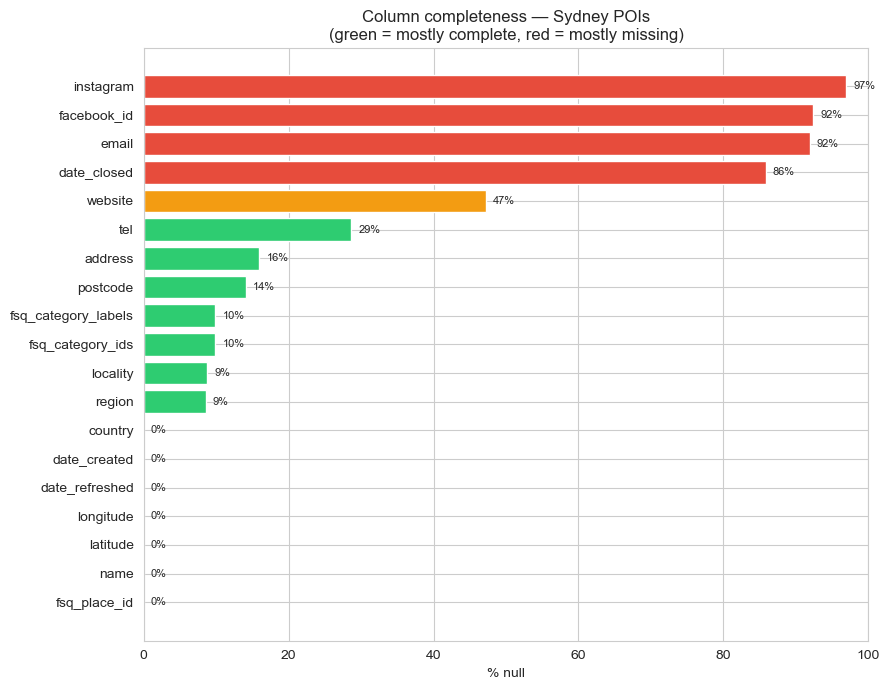

In [4]:
missingness = (sydney.isna().mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ecc71' if v < 30 else '#f39c12' if v < 70 else '#e74c3c' for v in missingness]
ax.barh(missingness.index, missingness.values, color=colors)
ax.set_xlabel("% null")
ax.set_title("Column completeness — Sydney POIs\n(green = mostly complete, red = mostly missing)")
ax.set_xlim(0, 100)
for i, v in enumerate(missingness):
    ax.text(v + 1, i, f"{v:.0f}%", va='center', fontsize=8)
plt.tight_layout()
plt.show()

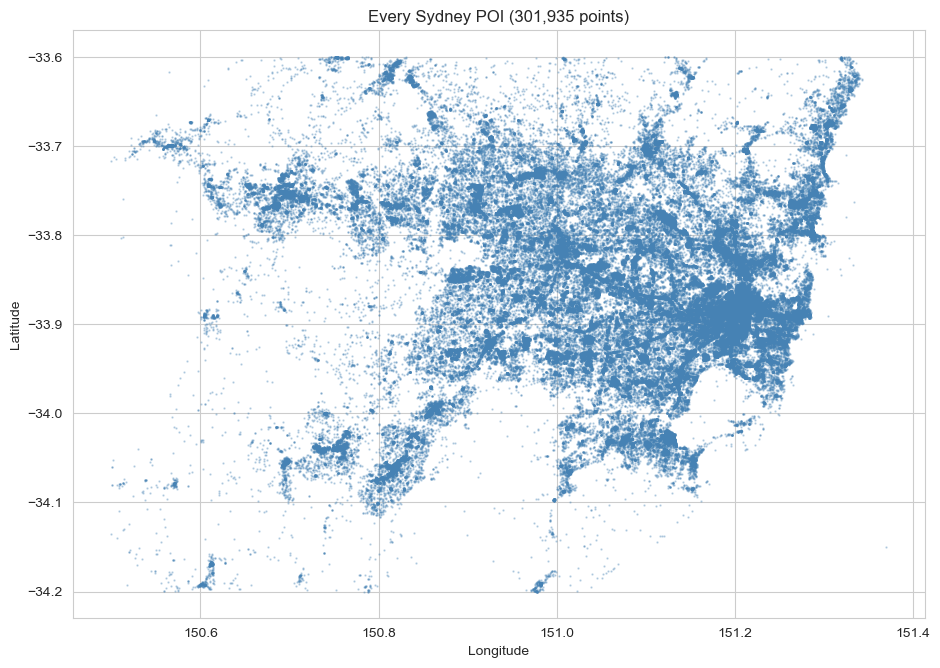

In [5]:
fig, ax = plt.subplots(figsize=(11, 11))
ax.scatter(sydney['longitude'], sydney['latitude'],
           s=0.5, alpha=0.3, color='steelblue')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Every Sydney POI ({len(sydney):,} points)")
ax.set_aspect('equal')
plt.show()

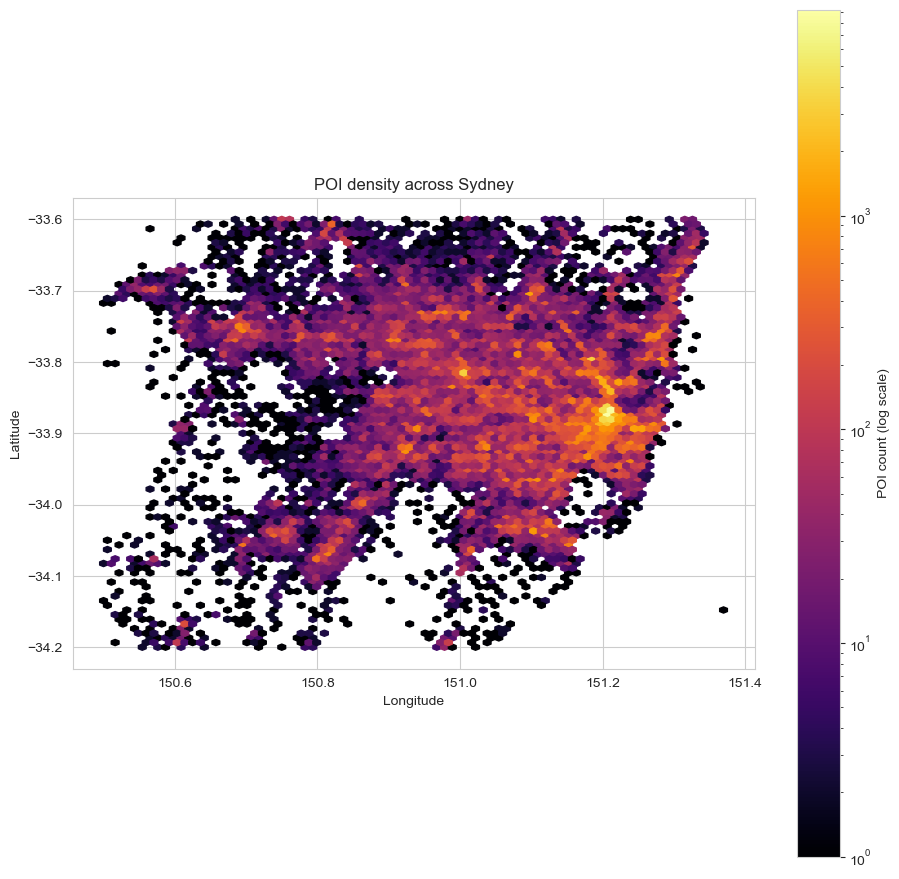

In [6]:
fig, ax = plt.subplots(figsize=(11, 11))
hb = ax.hexbin(sydney['longitude'], sydney['latitude'],
               gridsize=80, cmap='inferno', mincnt=1, bins='log')
plt.colorbar(hb, ax=ax, label='POI count (log scale)')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("POI density across Sydney")
ax.set_aspect('equal')
plt.show()

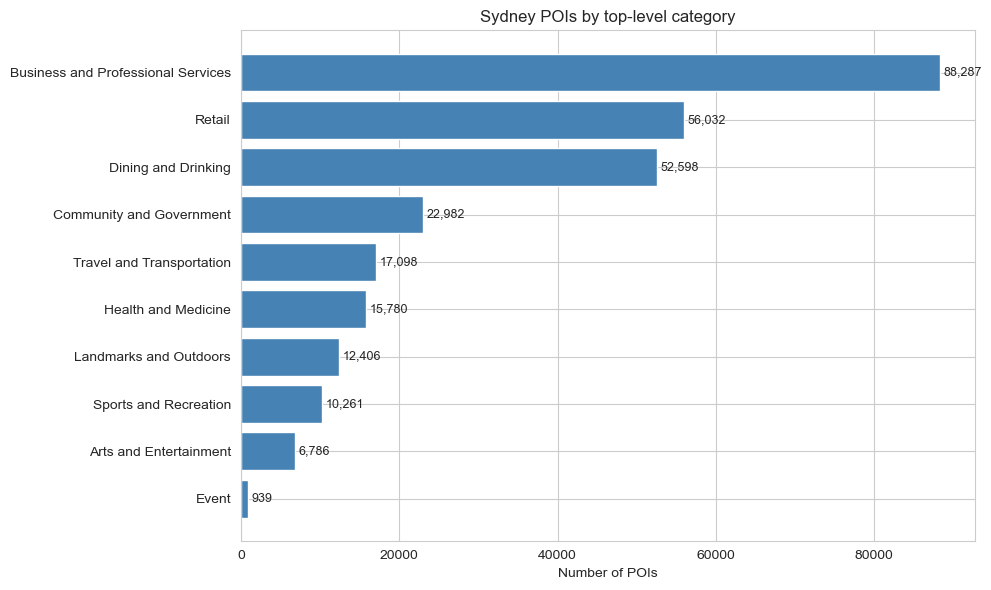

In [7]:
level1_counts = Counter()
for labels in sydney['fsq_category_labels']:
    if not isinstance(labels, (list, tuple, np.ndarray)) or len(labels) == 0:
        continue
    for top in {label.split(' > ')[0] for label in labels}:
        level1_counts[top] += 1

l1 = pd.Series(level1_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(l1.index, l1.values, color='steelblue')
ax.set_xlabel("Number of POIs")
ax.set_title("Sydney POIs by top-level category")
for i, v in enumerate(l1):
    ax.text(v + max(l1)*0.005, i, f"{v:,}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

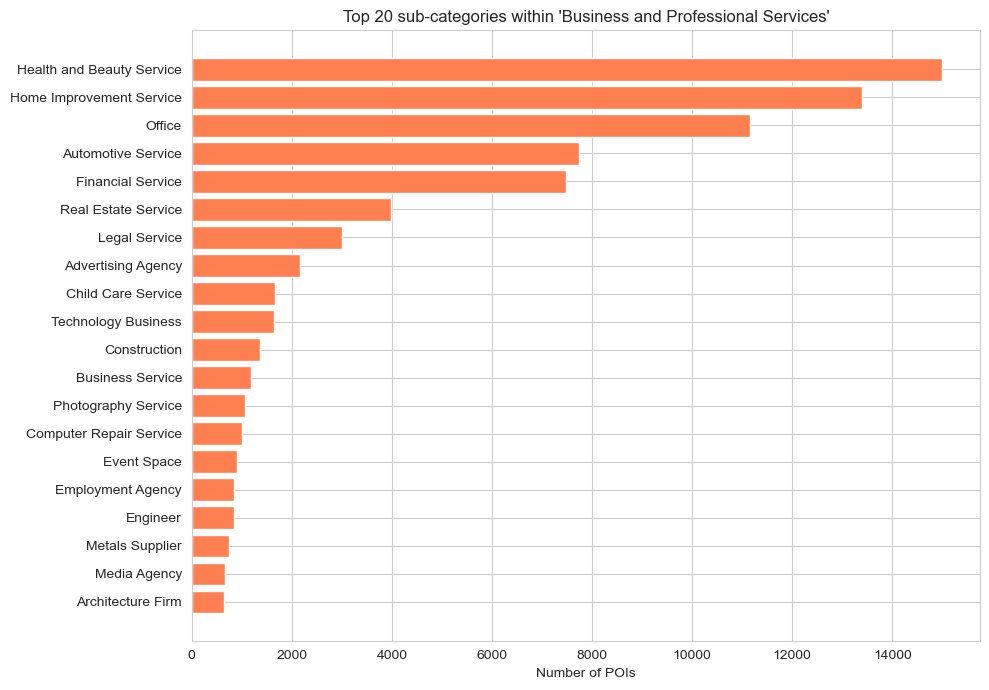

In [8]:
top_level1 = l1.idxmax()
level2_counts = Counter()
for labels in sydney['fsq_category_labels']:
    if not isinstance(labels, (list, tuple, np.ndarray)) or len(labels) == 0:
        continue
    for label in labels:
        parts = label.split(' > ')
        if parts[0] == top_level1 and len(parts) >= 2:
            level2_counts[parts[1]] += 1

l2 = pd.Series(level2_counts).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(l2.index[::-1], l2.values[::-1], color='coral')
ax.set_xlabel("Number of POIs")
ax.set_title(f"Top 20 sub-categories within '{top_level1}'")
plt.tight_layout()
plt.show()

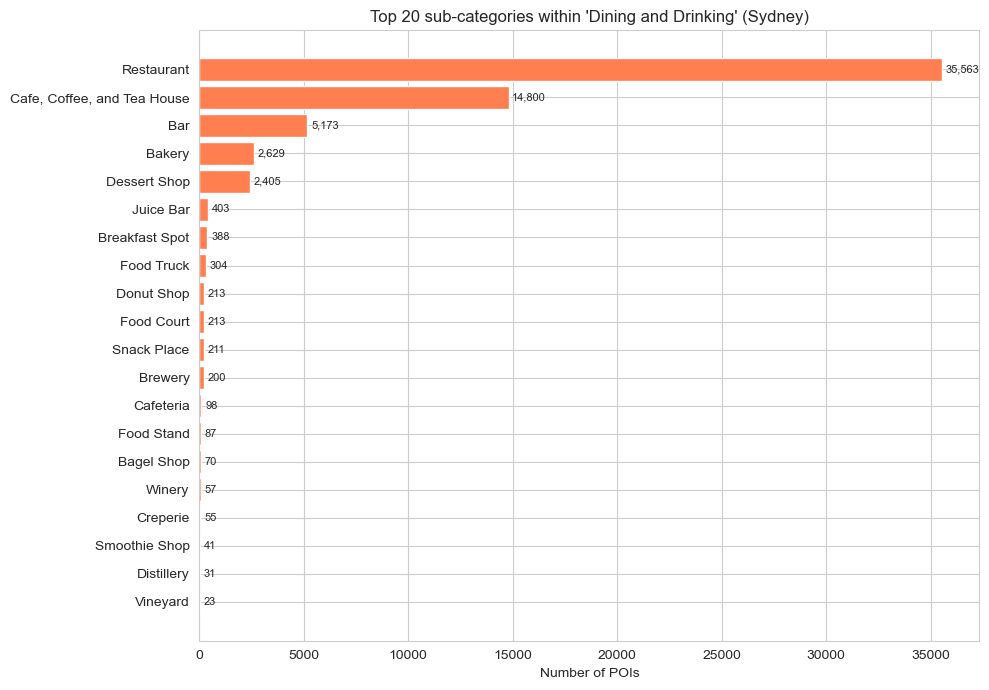

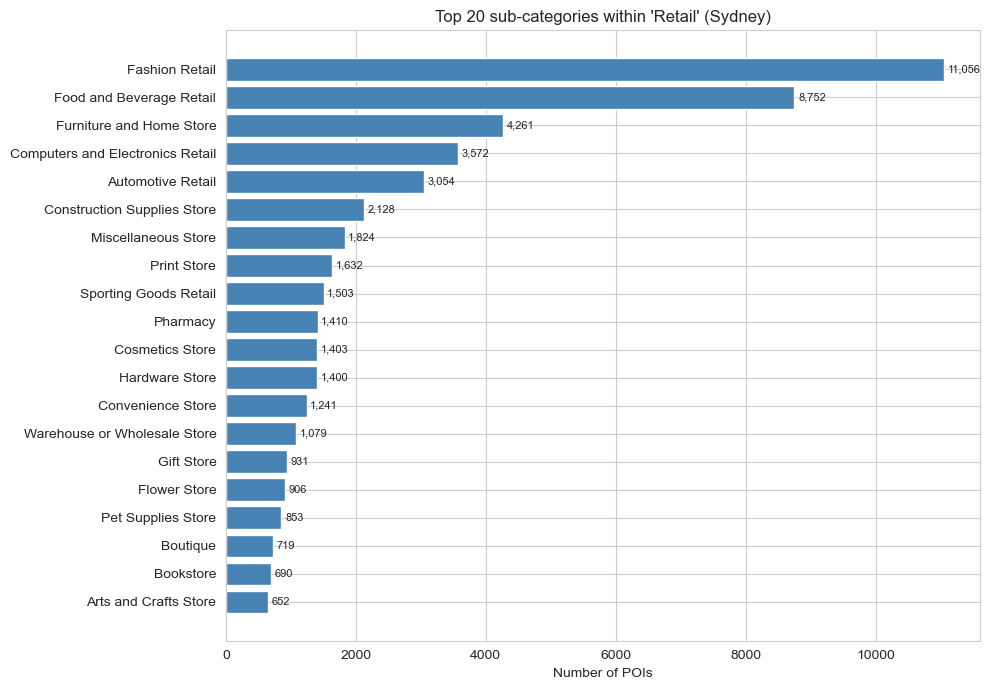

In [9]:
def plot_level2(sydney, level1_name, color='coral', top_n=20):
    """Plot the top N Level 2 sub-categories within a given Level 1 category."""
    counts = Counter()
    for labels in sydney['fsq_category_labels']:
        if not isinstance(labels, (list, tuple, np.ndarray)) or len(labels) == 0:
            continue
        for label in labels:
            parts = label.split(' > ')
            if parts[0] == level1_name and len(parts) >= 2:
                counts[parts[1]] += 1

    if not counts:
        print(f"No Level 2 sub-categories found under '{level1_name}'")
        return

    series = pd.Series(counts).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(series.index[::-1], series.values[::-1], color=color)
    ax.set_xlabel("Number of POIs")
    ax.set_title(f"Top {top_n} sub-categories within '{level1_name}' (Sydney)")
    for i, v in enumerate(series.values[::-1]):
        ax.text(v + max(series)*0.005, i, f"{v:,}", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

plot_level2(sydney, 'Dining and Drinking', color='coral')
plot_level2(sydney, 'Retail',              color='steelblue')

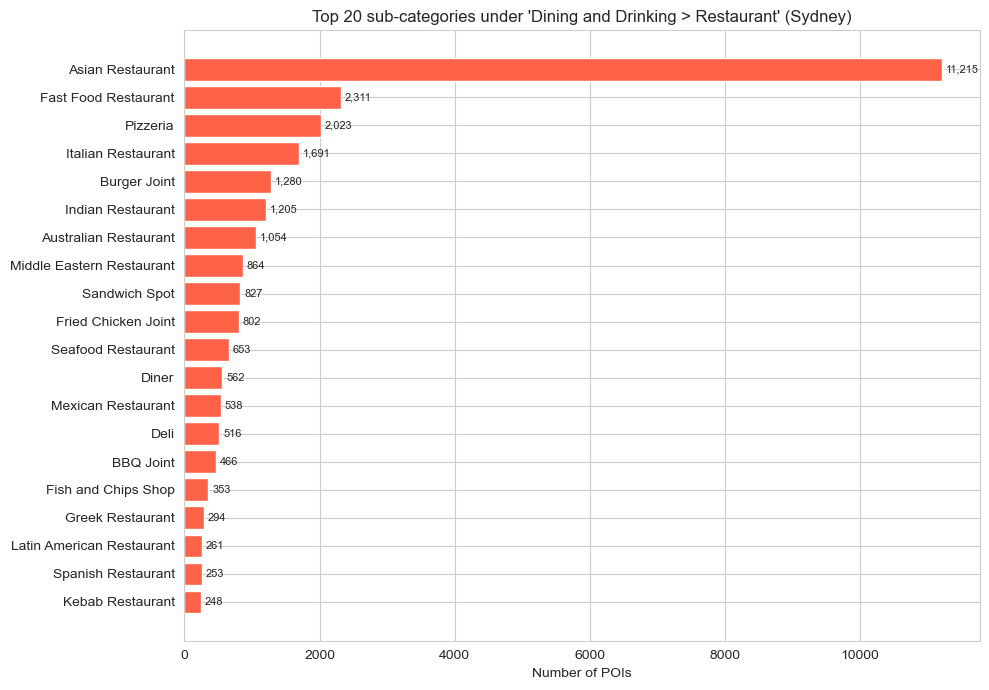

In [10]:
def plot_sub_categories(sydney, parent_path, color='coral', top_n=20):
    """
    Plot sub-categories one level below a given parent path.

    parent_path: e.g. 'Dining and Drinking' or 'Dining and Drinking > Restaurant'
    """
    parent_parts = parent_path.split(' > ')
    target_level = len(parent_parts)  # the level we want to count

    counts = Counter()
    for labels in sydney['fsq_category_labels']:
        if not isinstance(labels, (list, tuple, np.ndarray)) or len(labels) == 0:
            continue
        for label in labels:
            parts = label.split(' > ')
            # Does this label sit under the parent path, and go one level deeper?
            if len(parts) > target_level and parts[:target_level] == parent_parts:
                counts[parts[target_level]] += 1

    if not counts:
        print(f"No sub-categories found under '{parent_path}'")
        return

    series = pd.Series(counts).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(series.index[::-1], series.values[::-1], color=color)
    ax.set_xlabel("Number of POIs")
    ax.set_title(f"Top {top_n} sub-categories under '{parent_path}' (Sydney)")
    for i, v in enumerate(series.values[::-1]):
        ax.text(v + max(series)*0.005, i, f"{v:,}", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    return series

# Drill into restaurants specifically
restaurants = plot_sub_categories(sydney, 'Dining and Drinking > Restaurant', color='tomato')

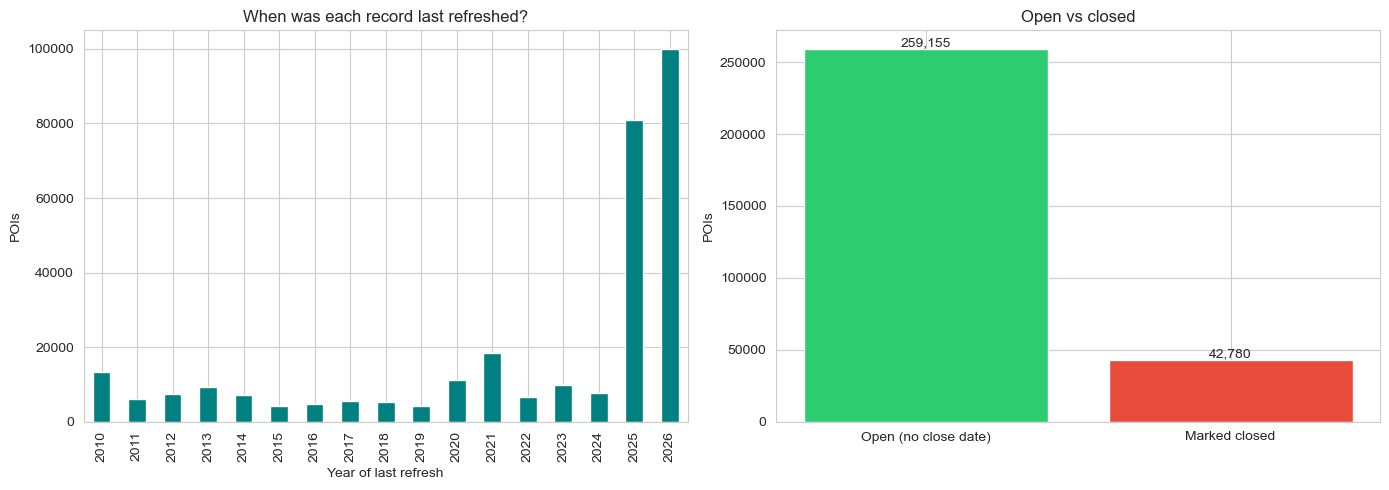

Records refreshed in the last 12 months: 177,522 (58.8%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: when records were last refreshed
sydney['date_refreshed'].dropna().dt.year.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='teal')
axes[0].set_title("When was each record last refreshed?")
axes[0].set_xlabel("Year of last refresh")
axes[0].set_ylabel("POIs")

# Right: open vs closed
status = pd.Series({
    'Open (no close date)': sydney['date_closed'].isna().sum(),
    'Marked closed':        sydney['date_closed'].notna().sum(),
})
axes[1].bar(status.index, status.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title("Open vs closed")
axes[1].set_ylabel("POIs")
for i, v in enumerate(status):
    axes[1].text(i, v, f"{v:,}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# A single number worth printing
recent = (sydney['date_refreshed'] >= pd.Timestamp.now() - pd.DateOffset(years=1)).sum()
print(f"Records refreshed in the last 12 months: {recent:,} ({recent/len(sydney):.1%})")

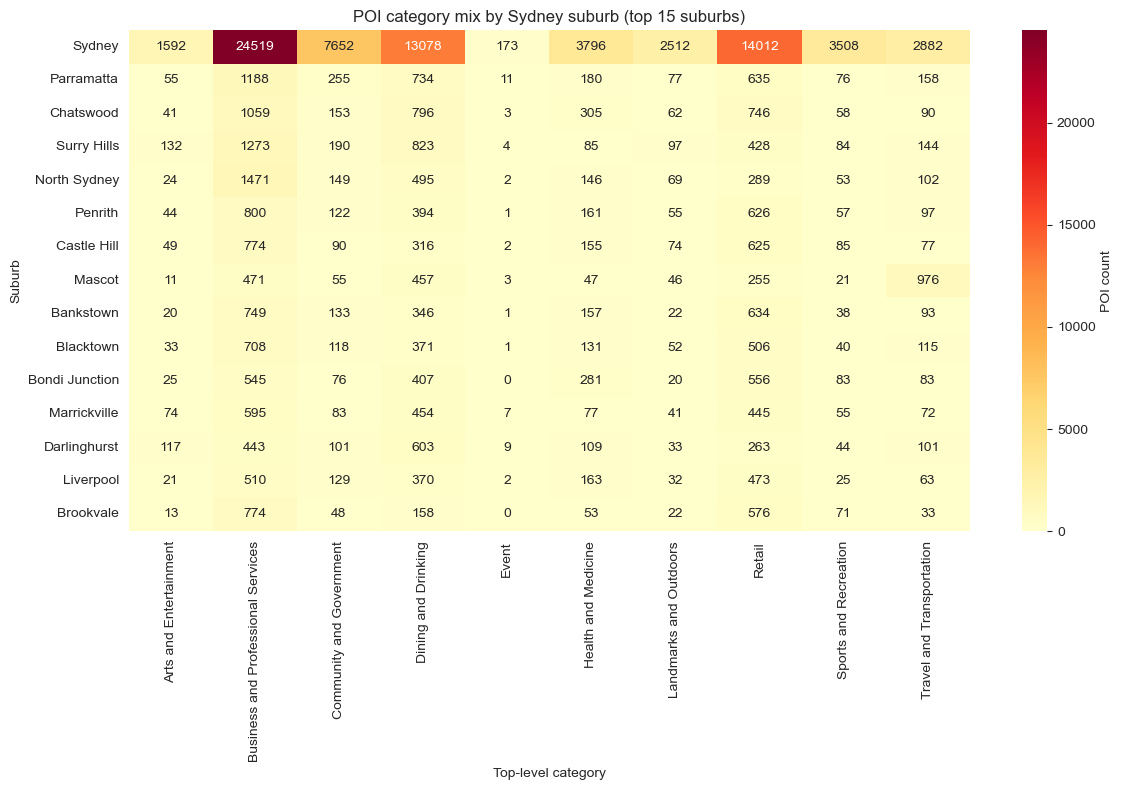

In [12]:
def first_level1(x):
    if not isinstance(x, (list, tuple, np.ndarray)) or len(x) == 0:
        return None
    return x[0].split(' > ')[0]

top_suburbs = sydney['locality'].value_counts().head(15).index
sub = sydney[sydney['locality'].isin(top_suburbs)].copy()
sub['level1'] = sub['fsq_category_labels'].apply(first_level1)

pivot = sub.pivot_table(index='locality', columns='level1',
                       values='fsq_place_id', aggfunc='count', fill_value=0)
pivot = pivot.loc[top_suburbs]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'POI count'})
ax.set_title("POI category mix by Sydney suburb (top 15 suburbs)")
ax.set_xlabel("Top-level category")
ax.set_ylabel("Suburb")
plt.tight_layout()
plt.show()

In [13]:
import h3
import numpy as np
import pandas as pd
from collections import Counter

# Non-commercial categories from the Foursquare docs — things like Tree, Road, Neighbourhood
NON_COMMERCIAL_IDS = {
    '4bf58dd8d48988d1f0931735','62d587aeda6648532de2b88c','4bf58dd8d48988d12b951735',
    '52f2ab2ebcbc57f1066b8b3b','50aa9e094b90af0d42d5de0d','5267e4d9e4b0ec79466e48c6',
    '5267e4d9e4b0ec79466e48c9','530e33ccbcbc57f1066bbff7','5345731ebcbc57f1066c39b2',
    '63be6904847c3692a84b9bb7','4d4b7105d754a06373d81259','5267e4d9e4b0ec79466e48c7',
    '4bf58dd8d48988d132951735','52f2ab2ebcbc57f1066b8b4c','50aaa4314b90af0d42d5de10',
    '58daa1558bbb0b01f18ec1fa','63be6904847c3692a84b9bb8','4f2a23984b9023bd5841ed2c',
    '5267e4d9e4b0ec79466e48d1','4f2a25ac4b909258e854f55f','5267e4d9e4b0ec79466e48c8',
    '52741d85e4b0d5d1e3c6a6d9','4bf58dd8d48988d1f7931735','4f4531504b9074f6e4fb0102',
    '4cae28ecbf23941eb1190695','4bf58dd8d48988d1f9931735','5bae9231bedf3950379f89c5',
    '530e33ccbcbc57f1066bbff8','530e33ccbcbc57f1066bbfe4','52f2ab2ebcbc57f1066b8b54',
    '5267e4d8e4b0ec79466e48c5','53e0feef498e5aac066fd8a9','4bf58dd8d48988d130951735',
    '530e33ccbcbc57f1066bbff3','5bae9231bedf3950379f89c3','4bf58dd8d48988d12a951735',
    '52e81612bcbc57f1066b7a24','530e33ccbcbc57f1066bbff9',
}

def is_commercial(cat_ids):
    if not isinstance(cat_ids, (list, tuple, np.ndarray)) or len(cat_ids) == 0:
        return False
    return not any(cid in NON_COMMERCIAL_IDS for cid in cat_ids)

# Start from the sydney df you already have
df = sydney.copy()

# Filter: open, has coordinates, has categories, is commercial
df = df[df['date_closed'].isna()]
df = df.dropna(subset=['latitude', 'longitude'])
df = df[df['fsq_category_ids'].apply(is_commercial)]

print(f"Commercial, open, geocoded Sydney POIs: {len(df):,}")

Commercial, open, geocoded Sydney POIs: 227,587


In [14]:
H3_RES = 8  # ~460m across, good for walkable catchments

df['h3'] = [h3.latlng_to_cell(lat, lon, H3_RES)
            for lat, lon in zip(df['latitude'], df['longitude'])]

def first_labels(labels):
    """Return (level1, level2) strings for the first category, or (None, None)."""
    if not isinstance(labels, (list, tuple, np.ndarray)) or len(labels) == 0:
        return (None, None)
    parts = labels[0].split(' > ')
    return (parts[0] if len(parts) >= 1 else None,
            parts[1] if len(parts) >= 2 else None)

df[['level1', 'level2']] = df['fsq_category_labels'].apply(
    lambda x: pd.Series(first_labels(x)))

# Flatten all category labels a place has, for diversity counts
def all_level2s(labels):
    if not isinstance(labels, (list, tuple, np.ndarray)):
        return []
    out = []
    for lbl in labels:
        parts = lbl.split(' > ')
        if len(parts) >= 2:
            out.append(parts[1])
    return out

df['all_level2'] = df['fsq_category_labels'].apply(all_level2s)

print(f"Unique hexes covered: {df['h3'].nunique():,}")
print(f"Median POIs per hex:  {df.groupby('h3').size().median():.0f}")

Unique hexes covered: 3,342
Median POIs per hex:  14


In [15]:
def neighbourhood(hex_id, k=1):
    """Return the hex plus its k rings of neighbours."""
    return h3.grid_disk(hex_id, k)

# Pre-group POIs by hex for fast lookup
hex_to_pois = df.groupby('h3')

# Get just the unique hex IDs that actually have POIs — these are our candidate zones
candidate_hexes = df['h3'].unique()
print(f"Candidate zones to score: {len(candidate_hexes):,}")

Candidate zones to score: 3,342


In [16]:
# "If I'm running a X, what other businesses nearby help my traffic?"
COMPLEMENTARY_MAP = {
    # Café benefits from: daytime workers, students, passing shoppers, gym/yoga crowd, early-morning commuters
    'Cafe, Coffee, and Tea House': [
        'Office',                        # daytime customers (coworking, consulting, tech)
        'Education',                     # students (unis dominate this bucket)
        'Gym and Studio',                # post-workout crowd
        'Fashion Retail',                # shopping foot traffic
        'Health and Beauty Service',     # hair/spa appointments = café waits
    ],

    # Restaurant benefits from: evening entertainment, lodging (tourists), nearby bars (pre/post dinner), shopping
    'Restaurant': [
        'Lodging',                       # tourists
        'Bar',                           # drinks before/after
        'Performing Arts Venue',         # dinner-and-a-show
        'Fashion Retail',                # shopping-then-eating
        'Movie Theater',                 # same
    ],

    # Bar benefits from: restaurants (post-dinner drinks), hotels, nightlife, offices (after-work crowd)
    'Bar': [
        'Restaurant',
        'Lodging',
        'Night Club',
        'Office',                        # after-work drinks
        'Performing Arts Venue',
    ],

    # Gym benefits from: daytime workers (lunchtime sessions), health-conscious retail, residential density
    'Gym and Studio': [
        'Office',
        'Cafe, Coffee, and Tea House',
        'Food and Beverage Retail',      # health food stores etc.
        'Health and Beauty Service',
        'Residential Building',
    ],

    # Bakery benefits from: foot traffic, cafés (synergy), schools (afternoon pickup), offices (morning)
    'Bakery': [
        'Cafe, Coffee, and Tea House',
        'Office',
        'Education',
        'Food and Beverage Retail',
        'Fashion Retail',
    ],
}

In [17]:
from math import radians, sin, cos, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

# Anchors are "things you measure distance to" — major foot-traffic drivers.
# Some need Level 3 filtering because the Level 2 bucket is too broad.
# Format: (level2_name, set_of_level3_names_or_None_for_all)

ANCHOR_RULES = {
    'rail':      ('Transport Hub', {'Rail Station', 'Metro Station', 'Light Rail Station', 'Tram Station'}),
    'bus':       ('Transport Hub', {'Bus Station'}),  # proper stations, not every bus stop
    'university': ('Education',    {'College and University'}),
    'school':    ('Education',     {'Primary and Secondary School', 'Preschool', 'Private School'}),
    'office':    ('Office',        None),  # whole bucket is office-ish
    'shopping':  ('Shopping Mall', None),  # dedicated Level 2 exists for this
    'hospital':  ('Hospital',      None),  # also a Level 2
    'hotel':     ('Lodging',       {'Hotel', 'Resort'}),
    'park':      ('Park',          None),
}

def matches_anchor(row, level2_name, level3_set):
    if row['level2'] != level2_name:
        return False
    if level3_set is None:
        return True
    labels = row['fsq_category_labels']
    if not isinstance(labels, (list, tuple, np.ndarray)):
        return False
    for lbl in labels:
        parts = lbl.split(' > ')
        if len(parts) >= 3 and parts[2] in level3_set:
            return True
    return False

anchor_coords = {}
for anchor_name, (level2_name, level3_set) in ANCHOR_RULES.items():
    mask = df.apply(lambda r: matches_anchor(r, level2_name, level3_set), axis=1)
    anchor_coords[anchor_name] = df.loc[mask, ['latitude','longitude']].values
    print(f"  {anchor_name:12s}: {mask.sum():,} POIs")

def build_features(target_hex, target_category_level2, k=1):
    """
    Compute a feature vector for a hex, scored for a business in `target_category_level2`.
    """
    ring = h3.grid_disk(target_hex, k)

    # Gather all POIs in the hex + k-ring
    pois_in_ring = []
    for h in ring:
        if h in hex_to_pois.groups:
            pois_in_ring.append(hex_to_pois.get_group(h))
    if not pois_in_ring:
        return None
    local = pd.concat(pois_in_ring)

    # --- Core features ---
    total_density = len(local)
    competitors = (local['level2'] == target_category_level2).sum()

    # Category diversity: how many unique Level 2 categories show up in the ring?
    # Using Shannon entropy on the mix — higher = more mixed-use
    level2_counts = local['level2'].value_counts()
    p = level2_counts / level2_counts.sum()
    diversity = -(p * np.log(p + 1e-12)).sum()

    # Complementary count — defined per-category via COMPLEMENTARY_MAP below
    complementary = sum(
        (local['level2'] == c).sum()
        for c in COMPLEMENTARY_MAP.get(target_category_level2, [])
    )

    # Centre of the target hex for distance calcs
    centre_lat, centre_lon = h3.cell_to_latlng(target_hex)

    # Distance to nearest *competitor* (if any exist at all in Sydney)
    comp_mask = df['level2'] == target_category_level2
    if comp_mask.any():
        comp_pts = df.loc[comp_mask, ['latitude','longitude']].values
        dists = np.array([haversine_km(centre_lat, centre_lon, la, lo)
                          for la, lo in comp_pts])
        nearest_competitor_km = dists.min()
    else:
        nearest_competitor_km = np.nan

    # Distance to nearest of each anchor type
    anchor_dists = {}
    for anchor_name, pts in anchor_coords.items():
        if len(pts) == 0:
            anchor_dists[f'dist_{anchor_name.lower()}_km'] = np.nan
            continue
        dists = np.array([haversine_km(centre_lat, centre_lon, la, lo)
                          for la, lo in pts])
        anchor_dists[f'dist_{anchor_name.lower()}_km'] = dists.min()

    return {
        'h3': target_hex,
        'centre_lat': centre_lat,
        'centre_lon': centre_lon,
        'total_density': total_density,
        'competitors': competitors,
        'complementary': complementary,
        'diversity_entropy': diversity,
        'unique_categories': level2_counts.size,
        'nearest_competitor_km': nearest_competitor_km,
        **anchor_dists,
    }

  rail        : 367 POIs
  bus         : 349 POIs
  university  : 3,204 POIs
  school      : 1,435 POIs
  office      : 9,424 POIs
  shopping    : 538 POIs
  hospital    : 592 POIs
  hotel       : 903 POIs
  park        : 4,137 POIs


In [18]:
TARGET_CATEGORY = 'Cafe, Coffee, and Tea House'  # matches Foursquare's Level 2

features = []
for i, hex_id in enumerate(candidate_hexes):
    row = build_features(hex_id, TARGET_CATEGORY, k=1)
    if row is not None:
        features.append(row)
    if i % 500 == 0:
        print(f"  ...{i}/{len(candidate_hexes)}")

feature_df = pd.DataFrame(features)
print(f"\nBuilt feature vectors for {len(feature_df):,} zones")
feature_df.head()

  ...0/3342
  ...500/3342
  ...1000/3342
  ...1500/3342
  ...2000/3342
  ...2500/3342
  ...3000/3342

Built feature vectors for 3,342 zones


,h3,centre_lat,centre_lon,total_density,competitors,complementary,diversity_entropy,unique_categories,nearest_competitor_km,dist_rail_km,dist_bus_km,dist_university_km,dist_school_km,dist_office_km,dist_shopping_km,dist_hospital_km,dist_hotel_km,dist_park_km
0,88be0e2c07fffff,-33.607622,151.145777,129,3,20,3.851915,64,0.862745,1.882190,3.696086,1.845639,0.387782,0.094601,0.906177,7.045713,0.436867,0.725110
1,88be0e2c3dfffff,-33.599241,151.141519,29,0,6,3.014630,23,1.488128,2.893789,4.548130,2.854010,1.046288,0.928973,1.499702,8.029932,0.583334,0.962702
2,88be0e2c39fffff,-33.606510,151.134937,117,4,17,3.704420,56,0.644302,2.520054,3.716207,2.437853,0.676341,0.933232,0.650246,7.381881,0.815682,0.800562
3,88be0e2c01fffff,-33.616004,151.150036,195,5,24,3.979559,79,0.850967,0.871513,2.947010,0.845972,0.399100,1.096912,1.128358,6.070626,1.445594,0.408614
4,88be0e2c03fffff,-33.614892,151.139195,159,3,23,3.936638,71,0.239161,1.595402,2.794952,1.493368,0.407768,1.021221,0.224773,6.378120,1.241742,0.155946


In [19]:
# Commercial anchor categories — if none of these exist in the k-ring, it's a residential zone
RETAIL_LEVEL2 = {
    'Fashion Retail', 'Food and Beverage Retail', 'Furniture and Home Store',
    'Computers and Electronics Retail', 'Cosmetics Store', 'Sporting Goods Retail',
    'Automotive Retail', 'Miscellaneous Store', 'Hardware Store', 'Pharmacy',
    'Convenience Store', 'Department Store', 'Shopping Mall', 'Gift Store',
    'Bookstore', 'Pet Supplies Store', 'Flower Store', 'Boutique',
    'Newsagent', 'Eyecare Store', 'Toy Store', 'Discount Store',
}
FOOD_BEV_LEVEL2 = {
    'Restaurant', 'Bar', 'Bakery', 'Dessert Shop', 'Cafe, Coffee, and Tea House',
}

def commercial_counts(hex_id, k=1):
    """Count retail and F&B POIs at two scales: the hex itself, and the k-ring."""
    retail_hex = food_hex = 0
    retail_ring = food_ring = 0

    # Hex itself — "what's next door?"
    if hex_id in hex_to_pois.groups:
        sub = hex_to_pois.get_group(hex_id)
        retail_hex = sub['level2'].isin(RETAIL_LEVEL2).sum()
        food_hex   = sub['level2'].isin(FOOD_BEV_LEVEL2).sum()

    # k-ring including the hex — "what's in the broader walking distance?"
    ring = h3.grid_disk(hex_id, k)
    for h in ring:
        if h in hex_to_pois.groups:
            sub = hex_to_pois.get_group(h)
            retail_ring += sub['level2'].isin(RETAIL_LEVEL2).sum()
            food_ring   += sub['level2'].isin(FOOD_BEV_LEVEL2).sum()

    return retail_hex, food_hex, retail_ring, food_ring

# Rebuild the columns
counts = feature_df['h3'].apply(lambda h: pd.Series(
    commercial_counts(h, k=1),
    index=['retail_hex', 'food_hex', 'retail_count', 'food_count']))
# Drop old versions if they exist, then concat
for col in ['retail_hex', 'food_hex', 'retail_count', 'food_count']:
    if col in feature_df.columns:
        feature_df = feature_df.drop(columns=col)
feature_df = pd.concat([feature_df, counts], axis=1)

print(f"Hexes with any retail:        {(feature_df['retail_count'] > 0).sum():,} / {len(feature_df):,}")
print(f"Hexes with any F&B:           {(feature_df['food_count']   > 0).sum():,}")
print(f"Hexes that meet both floors:  {((feature_df['retail_count'] >= 5) | (feature_df['food_count'] >= 3)).sum():,}")

Hexes with any retail:        2,900 / 3,342
Hexes with any F&B:           2,751
Hexes that meet both floors:  2,440


In [20]:
# =============================================================================
# CENSUS OVERLAY
# Load ABS 2021 demographics at SA2 level and spatially join to our hexes.
# =============================================================================
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

BASE = 'abs_data/2021_GCP_SA2_for_NSW_short-header/2021 Census GCP Statistical Area 2 for NSW'

# Total population per SA2
g01 = pd.read_csv(f'{BASE}/2021Census_G01_NSW_SA2.csv',
                  usecols=['SA2_CODE_2021', 'Tot_P_P']) \
        .rename(columns={'Tot_P_P': 'population'})

# Median age + income per SA2
g02 = pd.read_csv(f'{BASE}/2021Census_G02_NSW_SA2.csv',
                  usecols=['SA2_CODE_2021', 'Median_age_persons',
                           'Median_tot_hhd_inc_weekly']) \
        .rename(columns={'Median_age_persons': 'median_age',
                         'Median_tot_hhd_inc_weekly': 'median_hhd_income_weekly'})

demographics = g01.merge(g02, on='SA2_CODE_2021')
demographics['SA2_CODE_2021'] = demographics['SA2_CODE_2021'].astype(str)

# SA2 polygons (NSW only, with area for density)
sa2 = gpd.read_file('abs_data/SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp')
sa2 = sa2[sa2['STE_NAME21'] == 'New South Wales'].copy()
sa2['area_km2'] = sa2.to_crs('EPSG:3577').geometry.area / 1e6
sa2 = sa2[['SA2_CODE21', 'SA2_NAME21', 'area_km2', 'geometry']] \
        .rename(columns={'SA2_CODE21': 'SA2_CODE_2021', 'SA2_NAME21': 'sa2_name'})
sa2 = sa2.merge(demographics, on='SA2_CODE_2021', how='left')
sa2['pop_density'] = sa2['population'] / sa2['area_km2']

# Spatial join: each hex centroid → containing SA2
hex_points = gpd.GeoDataFrame(
    feature_df[['h3', 'centre_lat', 'centre_lon']].copy(),
    geometry=[Point(lon, lat) for lat, lon
              in zip(feature_df['centre_lat'], feature_df['centre_lon'])],
    crs='EPSG:4326').to_crs(sa2.crs)

hex_with_demo = gpd.sjoin(hex_points, sa2, how='left', predicate='within')

# Attach demographic columns to feature_df
for col in ['median_hhd_income_weekly', 'median_age', 'pop_density', 'sa2_name']:
    feature_df[col] = hex_with_demo.set_index('h3')[col].reindex(feature_df['h3']).values

print(f"Hexes matched to SA2: {feature_df['median_hhd_income_weekly'].notna().sum():,} / {len(feature_df):,}")

Hexes matched to SA2: 3,174 / 3,342


In [21]:
# Competitors-per-complementary: "how saturated is this area for cafés specifically?"
# +5 in denominator prevents divide-by-zero / infinity in empty hexes.
feature_df['saturation'] = feature_df['competitors'] / (feature_df['complementary'] + 5)

In [22]:
# =============================================================================
# NORMALISATION
# Convert raw features into 0–1 scores where higher = better for the user.
# =============================================================================
import numpy as np

def _minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

def normalise(df):
    out = df.copy()

    # Log-transform heavily right-skewed count features
    for col in ['total_density', 'complementary', 'competitors', 'unique_categories']:
        out[f'{col}_log'] = np.log1p(out[col])

    # Higher-is-better: activity / demand
    out['foot_traffic_score']  = _minmax(out['total_density_log'])
    out['complementary_score'] = _minmax(out['complementary_log'])
    out['diversity_score']     = _minmax(out['diversity_entropy'])
    out['variety_score']       = _minmax(out['unique_categories_log'])

    # Lower-is-better: competition
    out['low_competition_score'] = 1 - _minmax(out['competitors_log'])
    out['low_saturation_score']  = 1 - _minmax(df['saturation'])

    # Proximity (closer = better)
    for anchor in ['rail', 'bus', 'university', 'school',
                   'office', 'shopping', 'hospital', 'hotel', 'park']:
        out[f'{anchor}_proximity_score'] = 1 - _minmax(out[f'dist_{anchor}_km'])

    # Census-derived demand features
    out['income_score']      = _minmax(np.log1p(df['median_hhd_income_weekly'].fillna(df['median_hhd_income_weekly'].median())))
    out['pop_density_score'] = _minmax(np.log1p(df['pop_density'].fillna(df['pop_density'].median())))

    # Age fit: peaks at 35 (young professionals + families), falls off either side
    TARGET_AGE = 35
    age_fit = 1 - (df['median_age'].fillna(TARGET_AGE) - TARGET_AGE).abs() / 40
    out['age_fit_score'] = age_fit.clip(0, 1)

    return out

scored = normalise(feature_df)

In [23]:
# =============================================================================
# SCORING — weights for a risk-averse first-time café founder
# =============================================================================
FIRST_TIMER_WEIGHTS = {
    # Supply side
    'low_saturation_score':       0.18,
    'complementary_score':        0.15,
    'low_competition_score':      0.10,
    'foot_traffic_score':         0.07,
    'office_proximity_score':     0.08,
    'rail_proximity_score':       0.07,
    'university_proximity_score': 0.05,
    'diversity_score':            0.05,
    # Demand side (census)
    'income_score':               0.12,
    'pop_density_score':          0.08,
    'age_fit_score':              0.05,
}
assert abs(sum(FIRST_TIMER_WEIGHTS.values()) - 1.0) < 1e-6

scored['score'] = sum(scored[col] * w for col, w in FIRST_TIMER_WEIGHTS.items())

In [24]:
# =============================================================================
# COMMERCIAL VIABILITY FILTER
# A hex must have BOTH: at least 2 retail/F&B venues inside the hex itself,
# AND 15+ retail (or 10+ F&B) in the k-ring — i.e. a real shopping strip.
# =============================================================================
in_hex_commercial = (feature_df['retail_hex'] >= 2) | (feature_df['food_hex'] >= 2)
ring_strip        = (feature_df['retail_count'] >= 15) | (feature_df['food_count'] >= 10)
commercial_viable = in_hex_commercial & ring_strip

scored.loc[~commercial_viable, 'score'] = 0
print(f"Commercially viable hexes: {commercial_viable.sum():,} / {len(feature_df):,}")

Commercially viable hexes: 1,566 / 3,342


In [25]:
# =============================================================================
# HUMAN-READABLE EXPLANATION
# Given a hex, return a bulleted list of why it scored well.
# =============================================================================
def explain_hex(feature_row, all_features):
    reasons = []

    def percentile(series, value):
        return (series < value).mean()

    # --- POI-based signals ---
    pct_density       = percentile(all_features['total_density'],   feature_row['total_density'])
    pct_complementary = percentile(all_features['complementary'],   feature_row['complementary'])
    pct_competitors   = percentile(all_features['competitors'],     feature_row['competitors'])
    pct_saturation    = percentile(all_features['saturation'],
                                   feature_row['competitors'] / (feature_row['complementary'] + 5))

    if pct_density > 0.80:
        reasons.append(f"High foot traffic — {int(feature_row['total_density'])} POIs within 1km "
                       f"(top {int((1-pct_density)*100)}% in Sydney)")

    if pct_complementary > 0.75:
        reasons.append(f"Strong café-friendly neighbours — "
                       f"{int(feature_row['complementary'])} offices/gyms/schools/shops nearby")

    if feature_row['competitors'] == 0:
        reasons.append("No direct competitors within 1km (verify foot traffic is sufficient)")
    elif pct_competitors < 0.50:
        reasons.append(f"Manageable competition — only {int(feature_row['competitors'])} competing cafés "
                       f"(below Sydney median)")

    if pct_saturation < 0.30:
        reasons.append(f"Underserved for cafés — low saturation relative to foot traffic "
                       f"(bottom {int(pct_saturation*100)}% in Sydney)")

    # --- Distance signals ---
    if feature_row['dist_rail_km'] < 0.4:
        reasons.append(f"{int(feature_row['dist_rail_km']*1000)}m from nearest rail station")
    elif feature_row['dist_rail_km'] < 1.0:
        reasons.append(f"{feature_row['dist_rail_km']:.1f}km from nearest rail station")

    if feature_row['dist_office_km'] < 0.3:
        reasons.append(f"Surrounded by offices ({int(feature_row['dist_office_km']*1000)}m to nearest)")

    if feature_row['dist_university_km'] < 0.5:
        reasons.append(f"Near university campus ({feature_row['dist_university_km']:.1f}km)")

    # --- Commercial activity ---
    if feature_row['retail_count'] >= 15:
        reasons.append(f"Established retail precinct — {int(feature_row['retail_count'])} shops nearby")
    elif feature_row['retail_count'] >= 5:
        reasons.append(f"Active commercial strip — {int(feature_row['retail_count'])} shops nearby")

    # --- Demographic signals ---
    income = feature_row.get('median_hhd_income_weekly')
    if pd.notna(income):
        pct_income = percentile(all_features['median_hhd_income_weekly'], income)
        if pct_income > 0.75:
            reasons.append(f"Affluent neighbourhood — median household income ${int(income):,}/week "
                           f"(top {int((1-pct_income)*100)}% in Sydney)")
        elif pct_income < 0.25:
            reasons.append(f"Budget-conscious area — median income ${int(income):,}/week "
                           f"(factor this into your pricing)")

    age = feature_row.get('median_age')
    if pd.notna(age) and 28 <= age <= 42:
        reasons.append(f"Café-friendly demographics — median age {int(age)}")

    density = feature_row.get('pop_density')
    if pd.notna(density) and percentile(all_features['pop_density'], density) > 0.80:
        reasons.append(f"Dense residential catchment — {int(density):,} people per km²")

    return reasons

In [26]:
# =============================================================================
# TOP-N SELECTION WITH GEOGRAPHIC DIVERSITY
# Greedy pick: highest score first, then filter out anything within min_km.
# =============================================================================
from math import radians, sin, cos, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

def diverse_top_n(scored_df, n=10, min_distance_km=2.0):
    ranked = scored_df.sort_values('score', ascending=False).reset_index(drop=True)
    picks = []
    for _, row in ranked.iterrows():
        if len(picks) >= n:
            break
        if all(haversine_km(row['centre_lat'], row['centre_lon'],
                            p['centre_lat'], p['centre_lon']) >= min_distance_km
               for p in picks):
            picks.append(row)
    return pd.DataFrame(picks)

top10 = diverse_top_n(scored, n=10, min_distance_km=2.0)

In [27]:
# =============================================================================
# REPORT
# =============================================================================
print("=" * 80)
print("TOP 10 LOCATIONS FOR A FIRST-TIME CAFÉ OWNER IN SYDNEY")
print("=" * 80)

for rank, (_, row) in enumerate(top10.iterrows(), 1):
    feature_row = feature_df.loc[feature_df['h3'] == row['h3']].iloc[0]
    sa2 = feature_row.get('sa2_name') or 'Unknown SA2'

    print(f"\n#{rank} — Score: {row['score']:.3f}  —  {sa2}")
    print(f"  📍 ({row['centre_lat']:.4f}, {row['centre_lon']:.4f})")
    print(f"  🔗 https://www.google.com/maps/@{row['centre_lat']},{row['centre_lon']},17z")
    print("  Why this hex:")
    for reason in explain_hex(feature_row, feature_df):
        print(f"    • {reason}")

TOP 10 LOCATIONS FOR A FIRST-TIME CAFÉ OWNER IN SYDNEY

#1 — Score: 0.857  —  Pyrmont
  📍 (-33.8670, 151.1955)
  🔗 https://www.google.com/maps/@-33.866951613234086,151.19548744286064,17z
  Why this hex:
    • High foot traffic — 15255 POIs within 1km (top 0% in Sydney)
    • Strong café-friendly neighbours — 3895 offices/gyms/schools/shops nearby
    • 94m from nearest rail station
    • Surrounded by offices (35m to nearest)
    • Near university campus (0.1km)
    • Established retail precinct — 2092 shops nearby
    • Café-friendly demographics — median age 37
    • Dense residential catchment — 13,609 people per km²

#2 — Score: 0.853  —  Surry Hills
  📍 (-33.8848, 151.2149)
  🔗 https://www.google.com/maps/@-33.88482367951055,151.2149200310084,17z
  Why this hex:
    • High foot traffic — 13940 POIs within 1km (top 0% in Sydney)
    • Strong café-friendly neighbours — 3834 offices/gyms/schools/shops nearby
    • 345m from nearest rail station
    • Surrounded by offices (58m to nea

In [28]:
# =============================================================================
# MAP
# Folium heatmap of all scored hexes + top-10 pins with popups.
# =============================================================================
import folium
import h3
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def score_to_color(score, vmin, vmax):
    rgba = cm.viridis(mcolors.Normalize(vmin, vmax)(score))
    return mcolors.to_hex(rgba)

drawable = scored[scored['score'] > 0].copy()
vmin, vmax = drawable['score'].min(), drawable['score'].max()

sydney_map = folium.Map(location=[-33.87, 151.21], zoom_start=11,
                        tiles='cartodbpositron')

# Heatmap layer
for _, row in drawable.iterrows():
    folium.Polygon(
        locations=h3.cell_to_boundary(row['h3']),
        fill=True, fill_color=score_to_color(row['score'], vmin, vmax),
        fill_opacity=0.55, weight=0,
        tooltip=f"Score: {row['score']:.3f}<br>"
                f"Competitors: {int(row['competitors'])}<br>"
                f"Complementary: {int(row['complementary'])}",
    ).add_to(sydney_map)

# Top-10 pins
for rank, (_, row) in enumerate(top10.iterrows(), 1):
    feature_row = feature_df.loc[feature_df['h3'] == row['h3']].iloc[0]
    sa2 = feature_row.get('sa2_name') or 'Unknown SA2'
    reasons_html = "<br>".join(f"• {r}" for r in explain_hex(feature_row, feature_df))
    popup_html = f"""
    <div style="font-family: sans-serif; width: 280px;">
      <h4 style="margin:0;">#{rank} — {sa2}</h4>
      <div style="font-size: 11px; color: #666; margin-bottom: 6px;">
        Score {row['score']:.3f} | ({row['centre_lat']:.4f}, {row['centre_lon']:.4f})
      </div>
      <div style="font-size: 12px;">{reasons_html}</div>
    </div>
    """
    folium.Marker(
        location=[row['centre_lat'], row['centre_lon']],
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"#{rank} — {sa2}",
        icon=folium.Icon(color='red', icon='info-sign'),
    ).add_to(sydney_map)

sydney_map

In [29]:
feature_df.to_parquet("feature_df_v2.parquet")
scored.to_parquet("scored_v2.parquet")
top10.to_csv("top10_v2.csv", index=False)
sydney_map.save("sydney_cafe_recommendations_v2.html")
print("Saved: feature_df_v2, scored_v2, top10_v2, sydney_cafe_recommendations_v2.html")

Saved: feature_df_v2, scored_v2, top10_v2, sydney_cafe_recommendations_v2.html
